# Exposicion visual del proyecto ARMD-AI

## Objetivo de este notebook

Este notebook existe para documentar y mostrar de forma clara las graficas principales que apoyan la exposicion del proyecto.

Aqui no se entrena el modelo. Aqui se explica:

- como se veian los datos antes y despues de la limpieza
- que variables son importantes
- que variables se excluyeron y por que
- donde aparecen valores raros o extremos en variables clinicas
- que mensajes clave se pueden defender en la exposicion


## Regla de trabajo del proyecto

Este proyecto se esta documentando y ejecutando en Jupyter Lab dentro del entorno Miniconda `armd-ai`.

Por esa razon, las graficas de exposicion tambien deben quedar respaldadas en notebook, no solo como archivos `.png` o scripts sueltos.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Image, display, Markdown
import pandas as pd

RUTA_PROYECTO = Path.cwd().resolve().parent
RUTA_PROCESADOS = RUTA_PROYECTO / "3.DATOS-PROCESADOS"
RUTA_GRAFICAS_EXPO = RUTA_PROYECTO / "2.VISUALIZACION-DATOS" / "EXPOSICION"
RUTA_GRAFICAS_EXPO.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

print(RUTA_PROCESADOS)
print(RUTA_GRAFICAS_EXPO)


D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\2.VISUALIZACION-DATOS\EXPOSICION


## Regenerar las graficas desde notebook

Este notebook debe poder regenerar las imagenes sin depender de correr scripts manualmente por fuera.

La siguiente celda genera directamente los `.png` dentro de `2.VISUALIZACION-DATOS/EXPOSICION`.


In [2]:
df_base = pd.read_csv(RUTA_PROCESADOS / "armd_s_aureus_base_limpia.csv")
df_resumen = pd.read_csv(RUTA_PROCESADOS / "resumen_filas_antes_despues.csv")
df_susc = pd.read_csv(RUTA_PROCESADOS / "tabla_susceptibilidad_antes_despues.csv")
df_nulos = pd.read_csv(RUTA_PROCESADOS / "comparacion_nulos.csv")
if "Unnamed: 0" in df_nulos.columns:
    df_nulos = df_nulos.rename(columns={"Unnamed: 0": "variable", "antes": "nulos_antes_pct", "despues": "nulos_despues_pct"})
df_verif = pd.read_csv(RUTA_PROCESADOS / "verificacion_variables_modelado.csv")
df_top_abx = pd.read_csv(RUTA_PROCESADOS / "tabla_top_antibioticos_limpios.csv")
df_cultivos = pd.read_csv(RUTA_PROCESADOS / "tabla_cultivos_limpios.csv")
df_sem = pd.read_csv(RUTA_PROCESADOS / "reporte_faltantes_semanticos.csv") if (RUTA_PROCESADOS / "reporte_faltantes_semanticos.csv").exists() else None
df_modelo_full = pd.read_csv(RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_abx_comorb.csv") if (RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_abx_comorb.csv").exists() else None


def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(RUTA_GRAFICAS_EXPO / nombre, dpi=220, bbox_inches="tight")
    plt.close(fig)


def cramers_v(x, y):
    tabla = pd.crosstab(x.fillna("SIN_DATO"), y.fillna("SIN_DATO"))
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        return np.nan
    observado = tabla.to_numpy(dtype=float)
    n = observado.sum()
    if n <= 1:
        return np.nan
    esperado = observado.sum(axis=1, keepdims=True) @ observado.sum(axis=0, keepdims=True) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((observado - esperado) ** 2 / esperado)
    phi2 = chi2 / n
    r, k = observado.shape
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan
    return float(np.sqrt(phi2_corr / denom))


def correlation_ratio(categories, values):
    datos = pd.DataFrame({"cat": categories, "val": pd.to_numeric(values, errors="coerce")}).dropna()
    if datos.empty or datos["cat"].nunique() < 2:
        return np.nan
    media_global = datos["val"].mean()
    ss_between = 0.0
    for _, grupo in datos.groupby("cat"):
        ss_between += len(grupo) * (grupo["val"].mean() - media_global) ** 2
    ss_total = ((datos["val"] - media_global) ** 2).sum()
    if ss_total <= 0:
        return np.nan
    return float(np.sqrt(ss_between / ss_total))


fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_resumen["etapa"], df_resumen["filas"], color=["#2a9d8f", "#e76f51"])
ax.set_title("Registros antes y despues de la limpieza")
ax.set_ylabel("Numero de filas")
for i, v in enumerate(df_resumen["filas"]):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
guardar(fig, "expo_01_resumen_limpieza.png")

fig, ax = plt.subplots(figsize=(9, 5))
tabla_obj = df_susc.set_index("susceptibility")[["antes", "despues"]].fillna(0)
tabla_obj.plot(kind="bar", ax=ax, color=["#577590", "#f9844a"])
ax.set_title("Distribucion de susceptibility antes y despues")
ax.set_ylabel("Conteo")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
guardar(fig, "expo_02_objetivo_antes_despues.png")

fig, ax = plt.subplots(figsize=(10, 6))
df_nulos_top = df_nulos.sort_values("nulos_antes_pct", ascending=False).head(10)
y = range(len(df_nulos_top))
ax.barh([i + 0.18 for i in y], df_nulos_top["nulos_antes_pct"], height=0.35, label="Antes", color="#8d99ae")
ax.barh([i - 0.18 for i in y], df_nulos_top["nulos_despues_pct"], height=0.35, label="Despues", color="#ef476f")
ax.set_yticks(list(y))
ax.set_yticklabels(df_nulos_top["variable"])
ax.invert_yaxis()
ax.set_xlabel("% nulos")
ax.set_title("Variables con mas nulos antes y despues")
ax.legend()
guardar(fig, "expo_03_nulos_antes_despues.png")

fig, ax = plt.subplots(figsize=(8, 5))
df_verif["decision"].value_counts().plot(kind="bar", ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_title("Decision metodologica sobre variables")
ax.set_ylabel("Numero de variables")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
guardar(fig, "expo_04_decision_variables.png")

for columna, nombre, titulo in [
    ("median_wbc", "expo_05_boxplot_median_wbc.png", "Boxplot global de median_wbc"),
    ("median_cr", "expo_06_boxplot_median_cr.png", "Boxplot global de median_cr"),
]:
    serie = pd.to_numeric(df_base[columna], errors="coerce").dropna()
    if not serie.empty:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.boxplot(serie, vert=False, patch_artist=True, boxprops={"facecolor": "#90be6d"})
        ax.set_title(titulo)
        ax.set_xlabel(columna)
        guardar(fig, nombre)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_top_abx["antibiotic"].head(10), df_top_abx["frecuencia"].head(10), color="#577590")
ax.invert_yaxis()
ax.set_title("Antibioticos mas frecuentes")
ax.set_xlabel("Conteo")
guardar(fig, "expo_07_top_antibioticos.png")

tabla_cult = pd.crosstab(df_base["culture_description"], df_base["susceptibility"], normalize="index") * 100
tabla_cult = tabla_cult.sort_values("Resistant", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
tabla_cult[["Susceptible", "Intermediate", "Resistant"]].plot(kind="bar", stacked=True, ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_title("Susceptibility por tipo de cultivo")
ax.set_ylabel("% dentro de cada cultivo")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
guardar(fig, "expo_08_cultivo_vs_susceptibilidad.png")

orden_edad = ["18-24 years", "25-34 years", "35-44 years", "45-54 years", "55-64 years", "65-74 years", "75-84 years", "85+ years"]
tabla_edad = pd.crosstab(df_base["age"], df_base["susceptibility"], normalize="index") * 100
tabla_edad = tabla_edad.reindex([x for x in orden_edad if x in tabla_edad.index])
fig, ax = plt.subplots(figsize=(10, 5))
tabla_edad[["Susceptible", "Intermediate", "Resistant"]].plot(kind="bar", ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_title("Distribucion de susceptibility por grupos de edad")
ax.set_ylabel("% dentro del grupo")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
guardar(fig, "expo_09_edad_vs_susceptibilidad.png")

fig, ax = plt.subplots(figsize=(8, 5))
cols_ward = ["hosp_ward_ICU", "hosp_ward_ER", "hosp_ward_IP", "hosp_ward_OP"]
etiquetas = ["ICU", "ER", "IP", "OP"]
valores = [pd.to_numeric(df_base[c], errors="coerce").fillna(0).mean() * 100 for c in cols_ward]
ax.bar(etiquetas, valores, color="#4d908e")
ax.set_title("Presencia de entornos hospitalarios")
ax.set_ylabel("% de registros con marca positiva")
guardar(fig, "expo_10_entorno_hospitalario.png")

if df_sem is not None and not df_sem.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    top_sem = df_sem.sort_values("porcentaje_faltante_semantico", ascending=False).head(10)
    ax.barh(top_sem["variable"], top_sem["porcentaje_faltante_semantico"], color="#f4a261")
    ax.invert_yaxis()
    ax.set_title("Top variables con faltantes semanticos")
    ax.set_xlabel("% faltante semantico")
    guardar(fig, "expo_11_faltantes_semanticos.png")

if df_modelo_full is not None and not df_modelo_full.empty:
    df_heatmap = df_modelo_full.copy()
    columnas_excluir = ["anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded", "order_time_jittered_utc"]
    df_heatmap = df_heatmap.drop(columns=[c for c in columnas_excluir if c in df_heatmap.columns])

    mapa_susc = {"Susceptible": 0, "Intermediate": 1, "Resistant": 2}
    df_heatmap["susceptibility"] = df_heatmap["susceptibility"].map(mapa_susc)

    columnas_objeto = df_heatmap.select_dtypes(include=["object"]).columns.tolist()
    for columna in columnas_objeto:
        codigos, categorias = pd.factorize(df_heatmap[columna].fillna("SIN_DATO"), sort=True)
        df_heatmap[columna] = codigos

    for columna in df_heatmap.columns:
        df_heatmap[columna] = pd.to_numeric(df_heatmap[columna], errors="coerce")

    corr = df_heatmap.corr(numeric_only=True)
    corr.to_csv(RUTA_PROCESADOS / "matriz_correlacion_modelado_completo.csv", index=True)

    correlacion_target = corr[["susceptibility"]].drop(index="susceptibility").rename(columns={"susceptibility": "correlacion_con_susceptibility"})
    correlacion_target["correlacion_absoluta"] = correlacion_target["correlacion_con_susceptibility"].abs()
    correlacion_target = correlacion_target.sort_values("correlacion_absoluta", ascending=False)
    correlacion_target.to_csv(RUTA_PROCESADOS / "correlacion_con_susceptibility_modelado_completo.csv", index=True)

    fig, ax = plt.subplots(figsize=(22, 18))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=False, cbar_kws={"shrink": 0.75}, ax=ax)
    ax.set_title("Heatmap de correlacion del dataset final de modelado", fontsize=16)
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
    guardar(fig, "expo_12_heatmap_correlacion_modelado_completo.png")

wbc_susc = df_base[["susceptibility", "median_wbc"]].copy()
wbc_susc["median_wbc"] = pd.to_numeric(wbc_susc["median_wbc"], errors="coerce")
orden_susc = ["Susceptible", "Intermediate", "Resistant"]
datos_box = [wbc_susc.loc[wbc_susc["susceptibility"] == clase, "median_wbc"].dropna() for clase in orden_susc if clase in wbc_susc["susceptibility"].unique()]
etiquetas_box = [clase for clase in orden_susc if clase in wbc_susc["susceptibility"].unique()]
if any(len(serie) > 0 for serie in datos_box):
    fig, ax = plt.subplots(figsize=(8, 5))
    box = ax.boxplot(datos_box, tick_labels=etiquetas_box, patch_artist=True)
    colores = ["#2a9d8f", "#e9c46a", "#e76f51"]
    for patch, color in zip(box["boxes"], colores[:len(box["boxes"])]):
        patch.set_facecolor(color)
    ax.set_title("Distribucion de median_wbc segun susceptibility")
    ax.set_ylabel("median_wbc")
    guardar(fig, "expo_13_boxplot_wbc_por_susceptibility.png")

graficas = sorted(RUTA_GRAFICAS_EXPO.glob("expo_*.png"))
print("Numero de graficas encontradas:", len(graficas))
for ruta in graficas:
    print("-", ruta.name)


C:\Users\Johan\AppData\Local\Temp\ipykernel_21672\2492398077.py:11: DtypeWarning: Columns (0: gender) have mixed types. Specify dtype option on import or set low_memory=False.
  df_modelo_full = pd.read_csv(RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_abx_comorb.csv") if (RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_abx_comorb.csv").exists() else None
C:\Users\Johan\AppData\Local\Temp\ipykernel_21672\2492398077.py:160: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_objeto = df_heatmap.select_dtypes(include=["object"]).columns.tolist()


Numero de graficas encontradas: 14
- expo_01_resumen_limpieza.png
- expo_02_objetivo_antes_despues.png
- expo_03_nulos_antes_despues.png
- expo_04_decision_variables.png
- expo_05_boxplot_median_wbc.png
- expo_06_boxplot_median_cr.png
- expo_07_top_antibioticos.png
- expo_08_cultivo_vs_susceptibilidad.png
- expo_09_edad_vs_susceptibilidad.png
- expo_10_entorno_hospitalario.png
- expo_11_faltantes_semanticos.png
- expo_12_heatmap_asociacion_susceptibility.png
- expo_12_heatmap_correlacion_modelado_completo.png
- expo_13_boxplot_wbc_por_susceptibility.png


## 1. Resumen de limpieza

### Grafica: `expo_01_resumen_limpieza.png`

### Que muestra
- compara el numero de registros antes y despues de la limpieza
- ayuda a demostrar si la limpieza fue conservadora o agresiva

### Como interpretarla
- si la diferencia es pequena, significa que la limpieza fue controlada
- eso es bueno porque no destruye informacion util innecesariamente

### Mensaje para la exposicion
- la limpieza mejoro consistencia sin reducir de forma drastica la base de trabajo


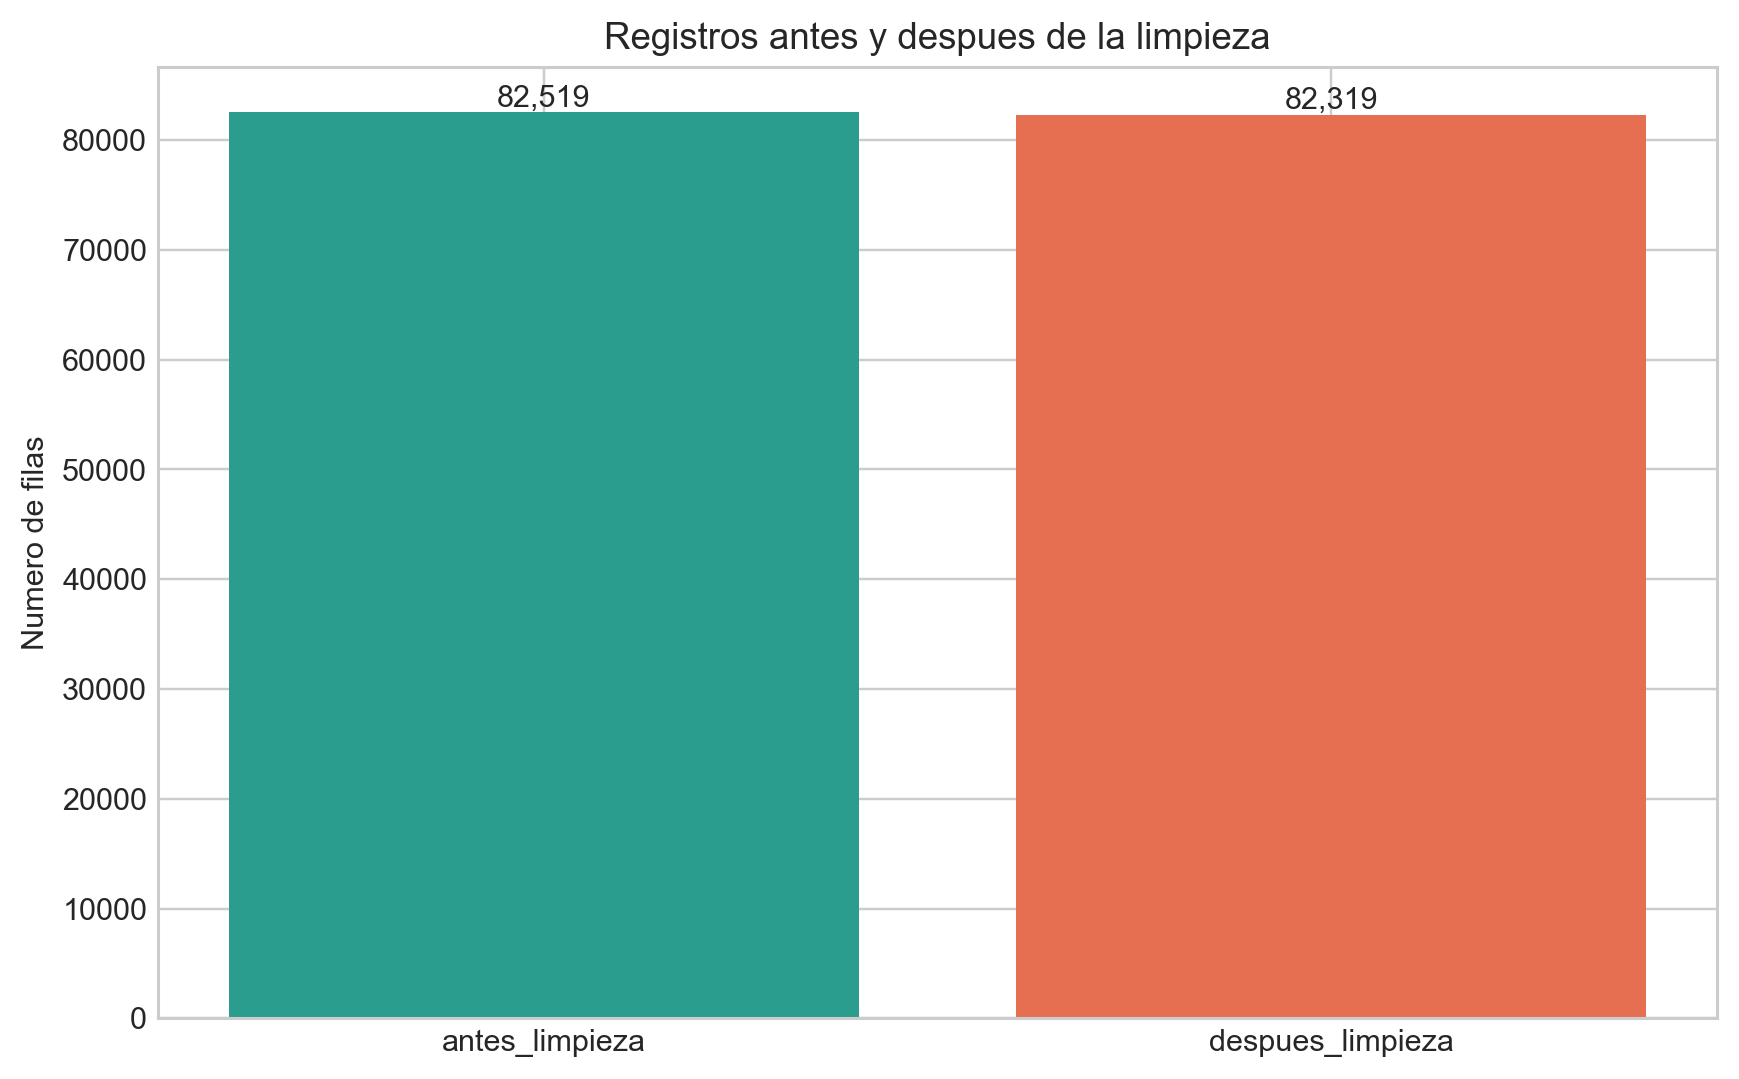

,etapa,filas,columnas,duplicados_exactos,ordenes_unicas
0,antes_limpieza,82519,25,0,8415
1,despues_limpieza,82319,25,0,8414


In [3]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_01_resumen_limpieza.png")))
display(pd.read_csv(RUTA_PROCESADOS / "resumen_filas_antes_despues.csv"))


## 2. Variable objetivo antes y despues

### Grafica: `expo_02_objetivo_antes_despues.png`

### Que muestra
- la distribucion de `susceptibility` antes y despues de la limpieza
- si habia clases vacias, raras o inutiles

### Por que da ese resultado
- el problema real esta dominado por `Susceptible`
- `Intermediate` es muy minoritaria
- habia algunos registros vacios o categorias no utiles que fueron retiradas

### Mensaje para la exposicion
- el problema esta desbalanceado y eso afecta el modelado
- la limpieza dejo una variable objetivo mas coherente para clasificacion multiclase


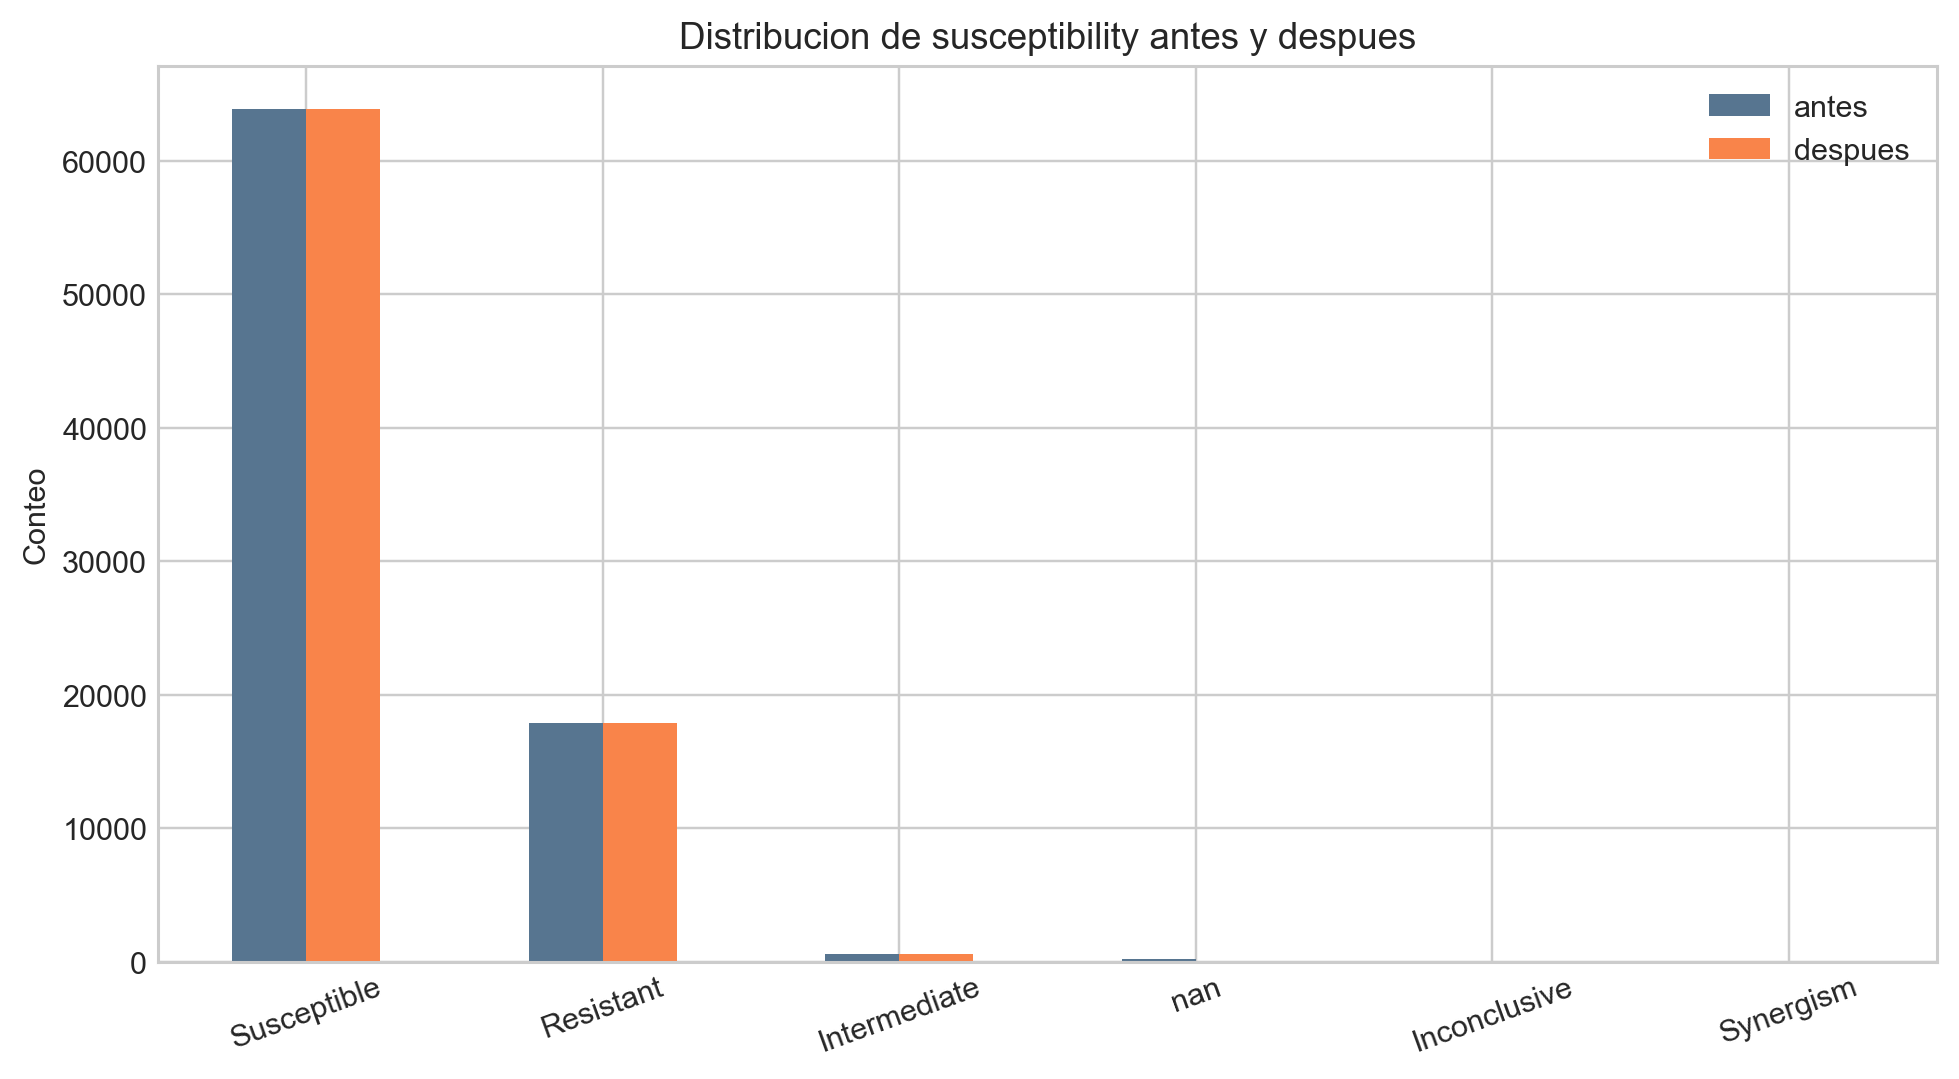

,susceptibility,antes,despues
0,Susceptible,63876,63876
1,Resistant,17866,17866
2,Intermediate,577,577
3,NaN,196,0
4,Inconclusive,4,0
5,Synergism,0,0


In [4]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_02_objetivo_antes_despues.png")))
display(pd.read_csv(RUTA_PROCESADOS / "tabla_susceptibilidad_antes_despues.csv"))


## 3. Nulos antes y despues

### Grafica: `expo_03_nulos_antes_despues.png`

### Que muestra
- las variables con mayor porcentaje de nulos antes y despues de la limpieza

### Por que da ese resultado
- algunas variables quedaron igual de vacias porque el problema viene desde la fuente
- otras mejoraron porque se convirtieron en categorias explicitas como `SIN_REGISTRO` o `SIN_REGLA`

### Mensaje para la exposicion
- no todos los problemas de calidad se resuelven borrando filas
- algunas variables se conservaron y otras se excluyeron segun cobertura y utilidad clinica


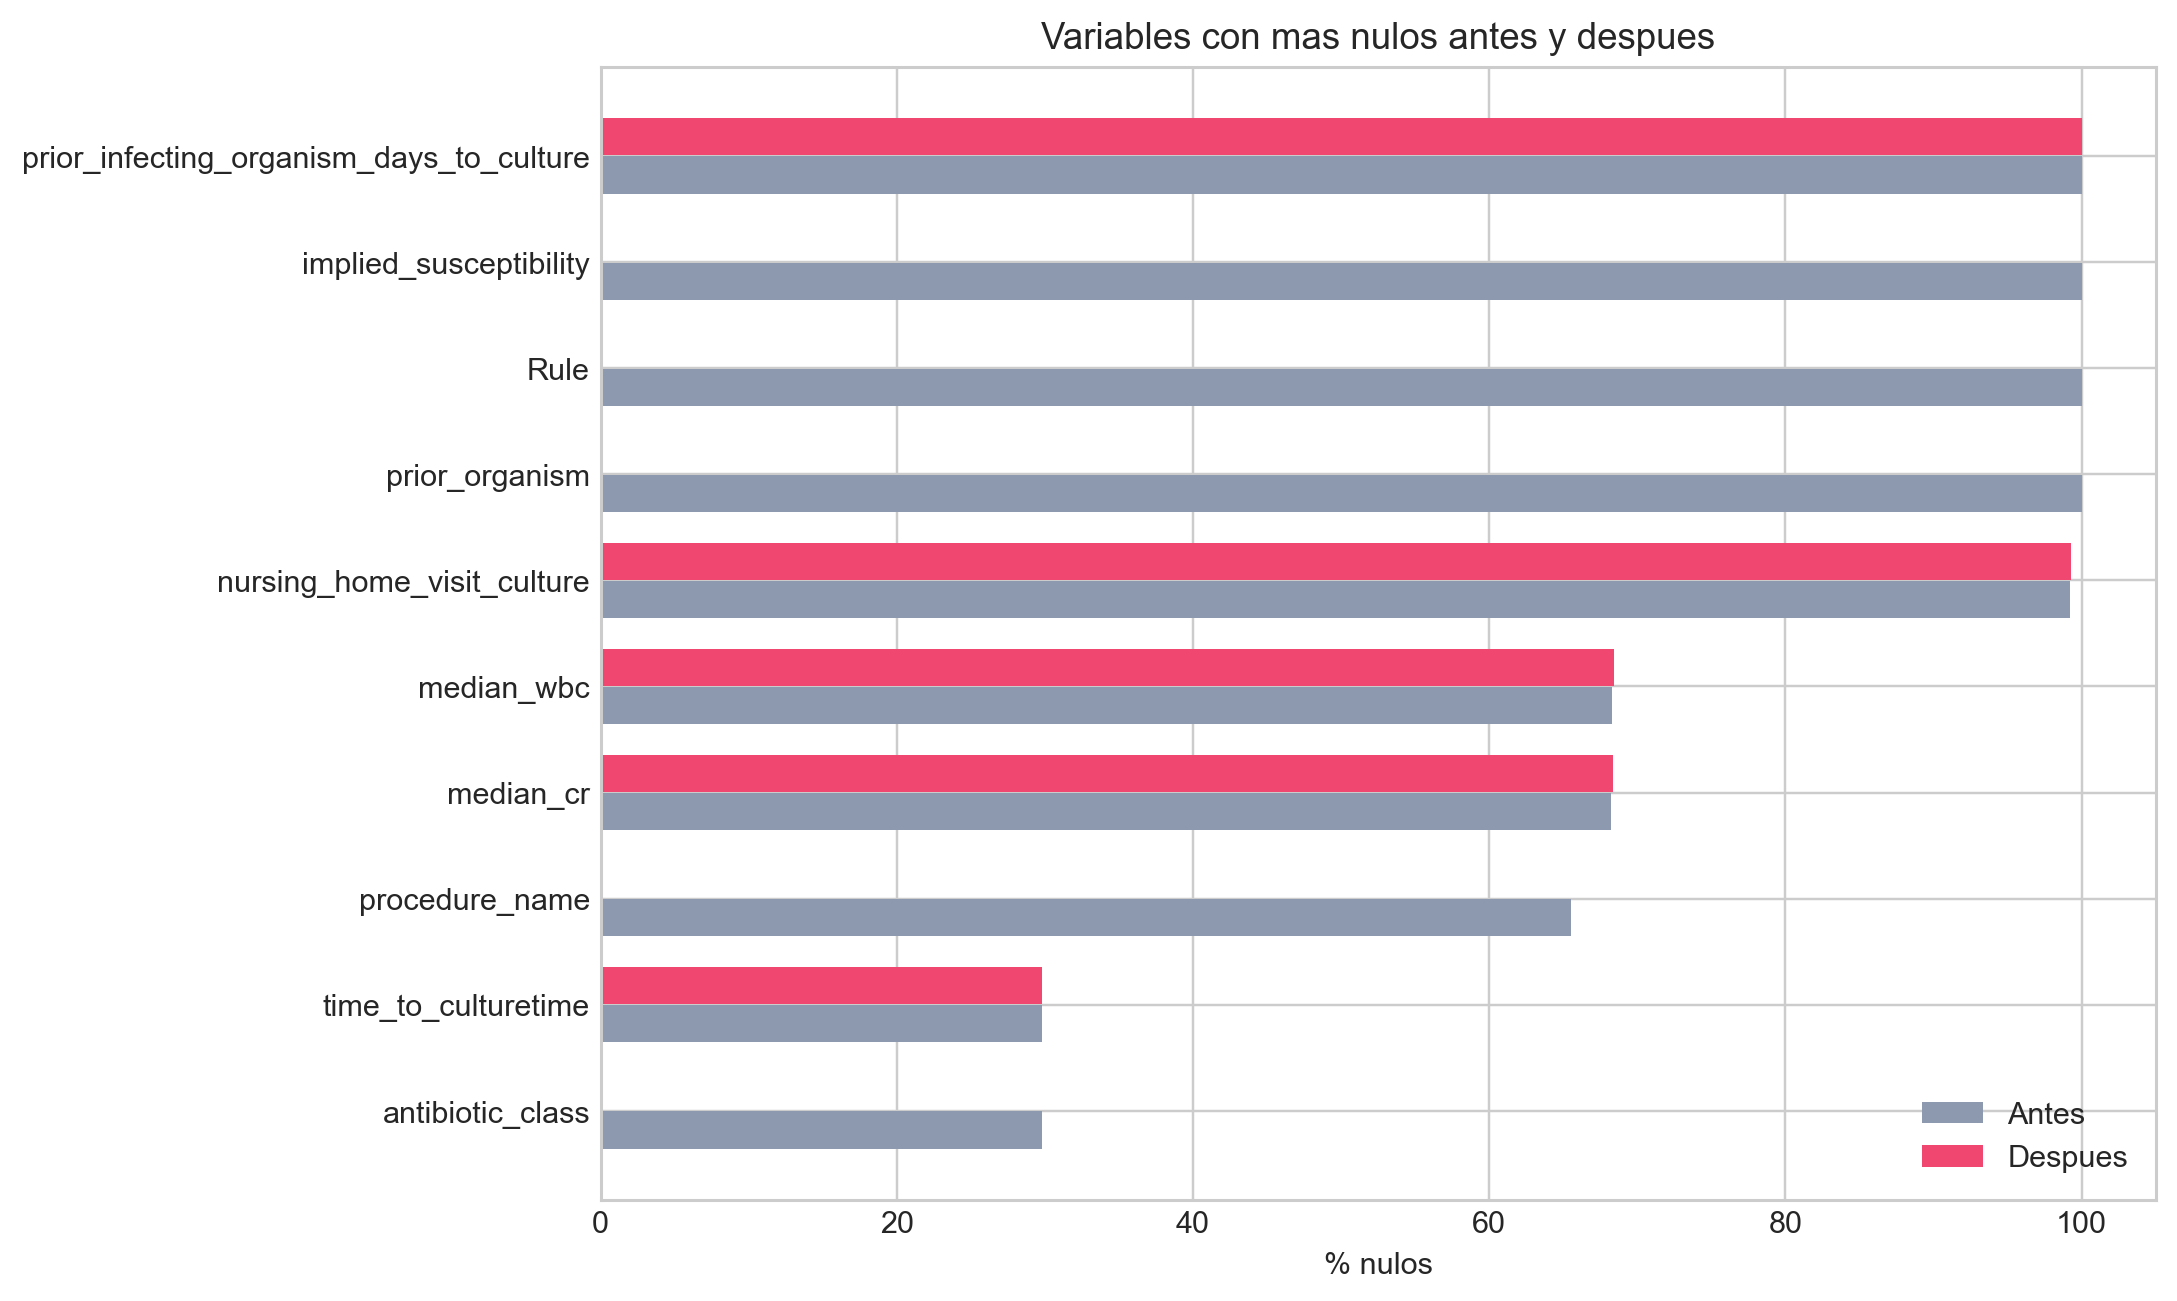

,Unnamed: 0,antes,despues
0,prior_infecting_organism_days_to_culture,100.000000,100.000000
1,implied_susceptibility,100.000000,0.000000
2,Rule,100.000000,0.000000
3,prior_organism,100.000000,0.000000
4,nursing_home_visit_culture,99.254717,99.257766
5,median_wbc,68.272761,68.416769
6,median_cr,68.217017,68.362104
7,procedure_name,65.515821,0.000000
8,time_to_culturetime,29.781020,29.769555
9,antibiotic_class,29.781020,0.000000


In [5]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_03_nulos_antes_despues.png")))
display(pd.read_csv(RUTA_PROCESADOS / "comparacion_nulos.csv"))


## 4. Decision final de variables

### Grafica: `expo_04_decision_variables.png`

### Que muestra
- cada variable, su porcentaje de nulos y la decision tecnica tomada
- `usar`, `usar con cuidado` o `excluir`

### Por que da ese resultado
- `culture_description`, `antibiotic`, `age` y las variables de entorno hospitalario tienen buena cobertura y sentido clinico
- `median_wbc`, `median_cr`, `ordering_mode`, `procedure_name` y exposicion antibiotica tienen valor, pero requieren cuidado
- `nursing_home_visit_culture`, `prior_organism`, `Rule` e `implied_susceptibility` no justifican entrar en esta iteracion

### Mensaje para la exposicion
- la seleccion de variables no fue arbitraria
- se baso en calidad de datos, cobertura, interpretabilidad y sentido clinico


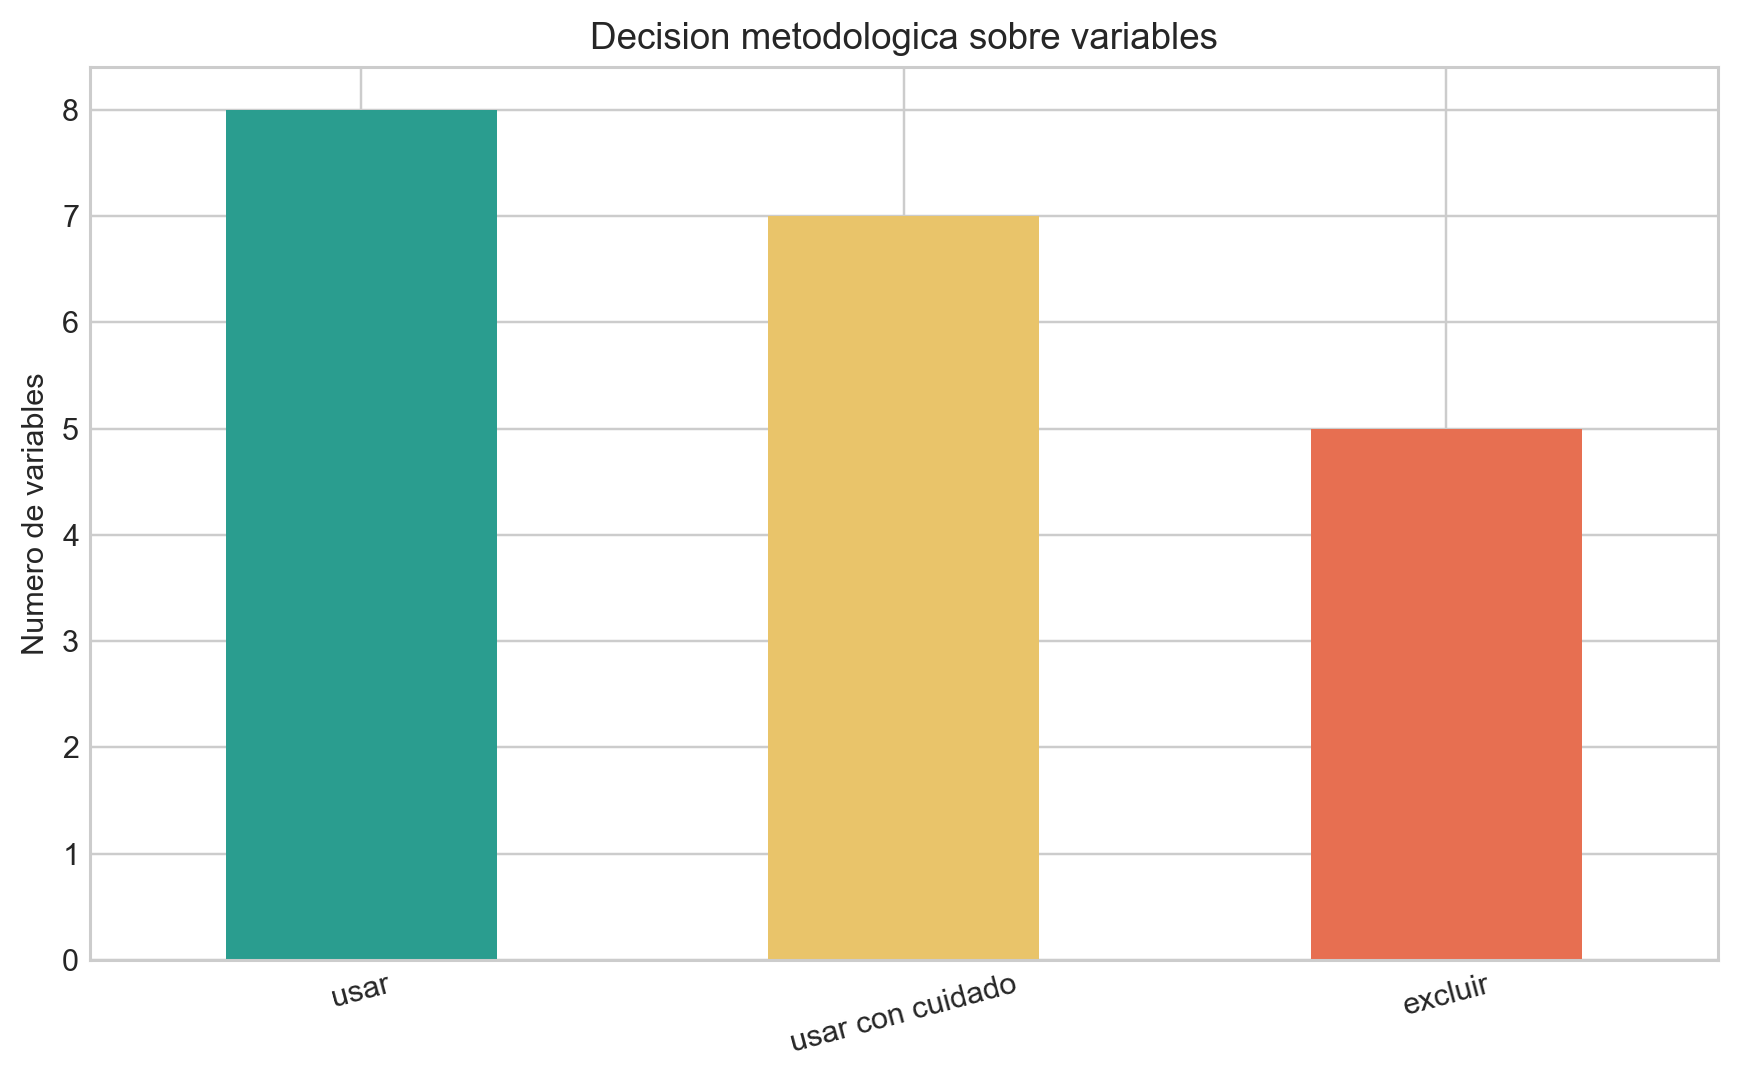

,variable,tipo,porcentaje_nulos,cardinalidad,decision,justificacion
0,prior_infecting_organism_days_to_culture,numerica,100.00,0,excluir,Quedo completamente vacia en esta version de l...
1,nursing_home_visit_culture,numerica,99.26,9,excluir,Tiene cerca de 99% de nulos. Mantenerla en est...
2,prior_organism,categorica,0.00,1,excluir,En esta version de la base quedo sin informaci...
3,implied_susceptibility,categorica,0.00,1,excluir,Para esta bacteria la fuente consultada llega ...
4,Rule,categorica,0.00,1,excluir,Quedo sin informacion util despues del cruce a...
5,culture_description,categorica,0.00,3,usar,Tiene fuerte sentido clinico y buena cobertura...
6,antibiotic,categorica,0.00,23,usar,"Es una variable central del problema, porque l..."
7,age,categorica,0.00,9,usar,Tiene sentido clinico y buena cobertura. La ed...
8,gender,categorica,0.00,3,usar,Tiene cobertura casi completa y puede mantener...
9,hosp_ward_ICU,binaria,0.00,2,usar,La UCI es clinicamente relevante por mayor pre...


In [6]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_04_decision_variables.png")))
display(pd.read_csv(RUTA_PROCESADOS / "verificacion_variables_modelado.csv"))


## 5. Boxplot de leucocitos

### Grafica: `expo_05_boxplot_median_wbc.png`

### Que muestra
- la distribucion de `median_wbc` por clase de `susceptibility`
- la mediana, el rango intercuartil y los valores atipicos

### Por que da ese resultado
- `median_wbc` mide respuesta inflamatoria o inmunologica
- en datos clinicos reales es normal encontrar colas largas y valores extremos
- por eso el profesor recomienda grafico de bigotes: deja ver dispersion y outliers con mucha claridad

### Mensaje para la exposicion
- la variable tiene sentido clinico
- pero tambien muestra variabilidad fuerte y muchos faltantes, por eso quedo como `usar con cuidado`


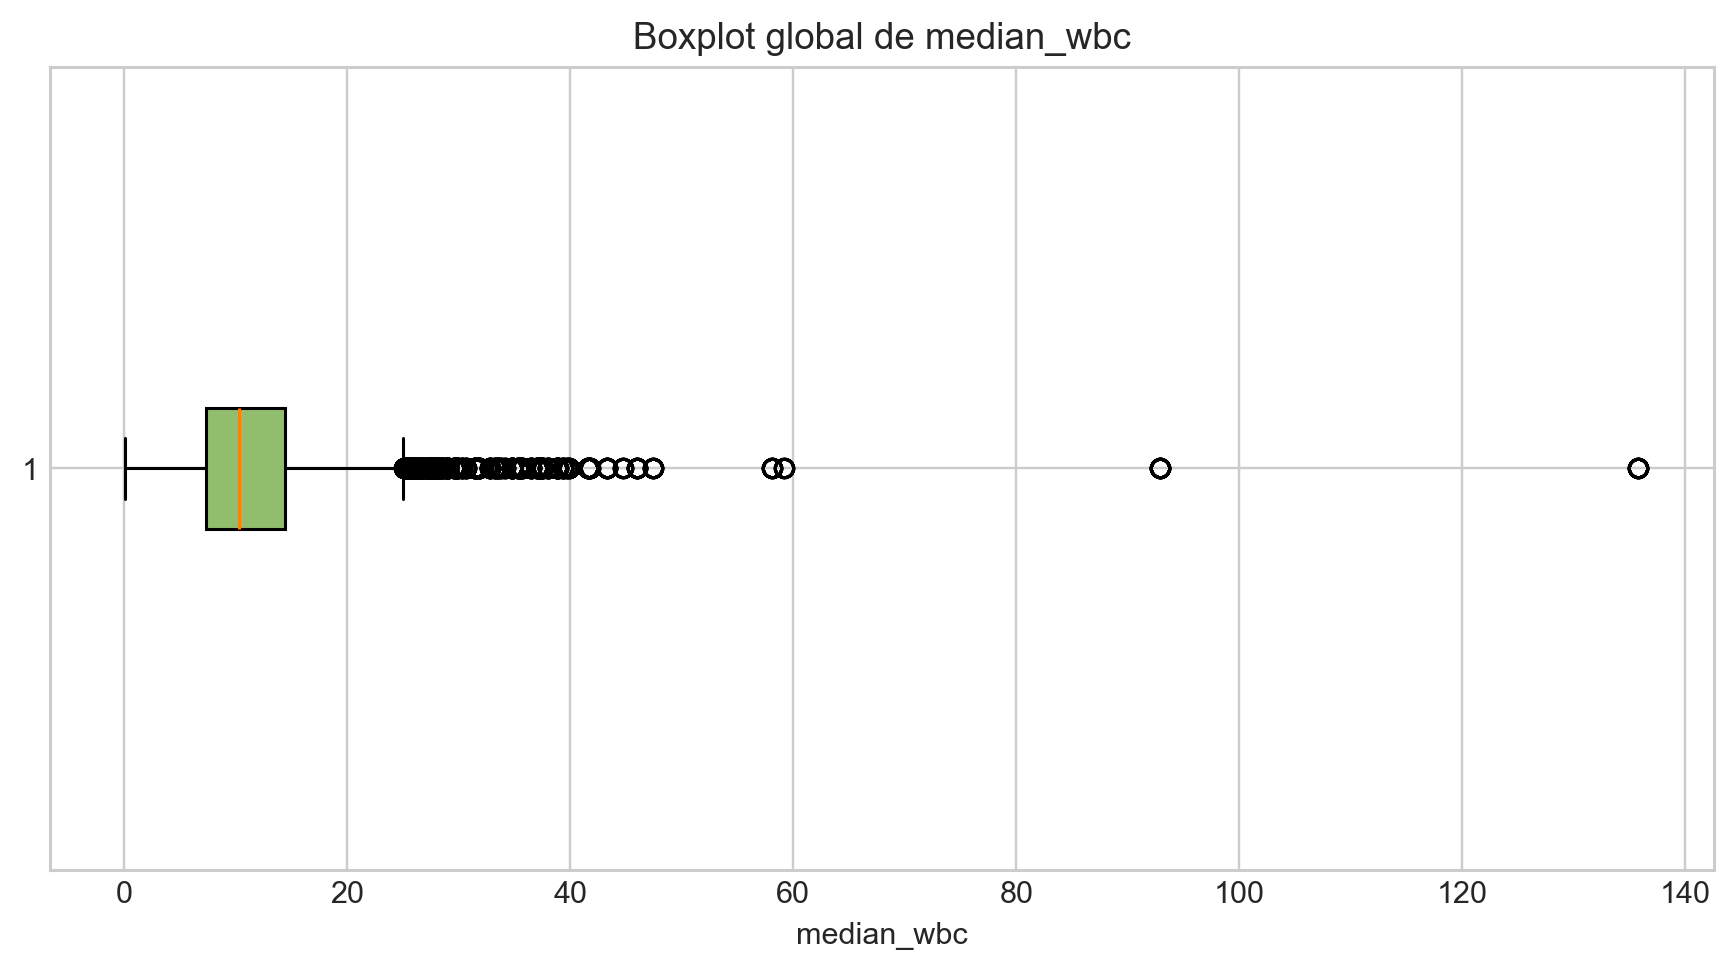

In [7]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_05_boxplot_median_wbc.png")))


## 6. Boxplot de creatinina

### Grafica: `expo_06_boxplot_median_cr.png`

### Que muestra
- la distribucion de `median_cr` por clase de `susceptibility`
- si existen valores extremos asociados a deterioro renal u otros contextos clinicos complejos

### Por que da ese resultado
- la creatinina es una variable sensible a funcion renal alterada
- en pacientes hospitalarios es comun ver dispersion y outliers

### Mensaje para la exposicion
- la variable es clinicamente valiosa
- pero necesita manejo cuidadoso en el pipeline por su cobertura limitada


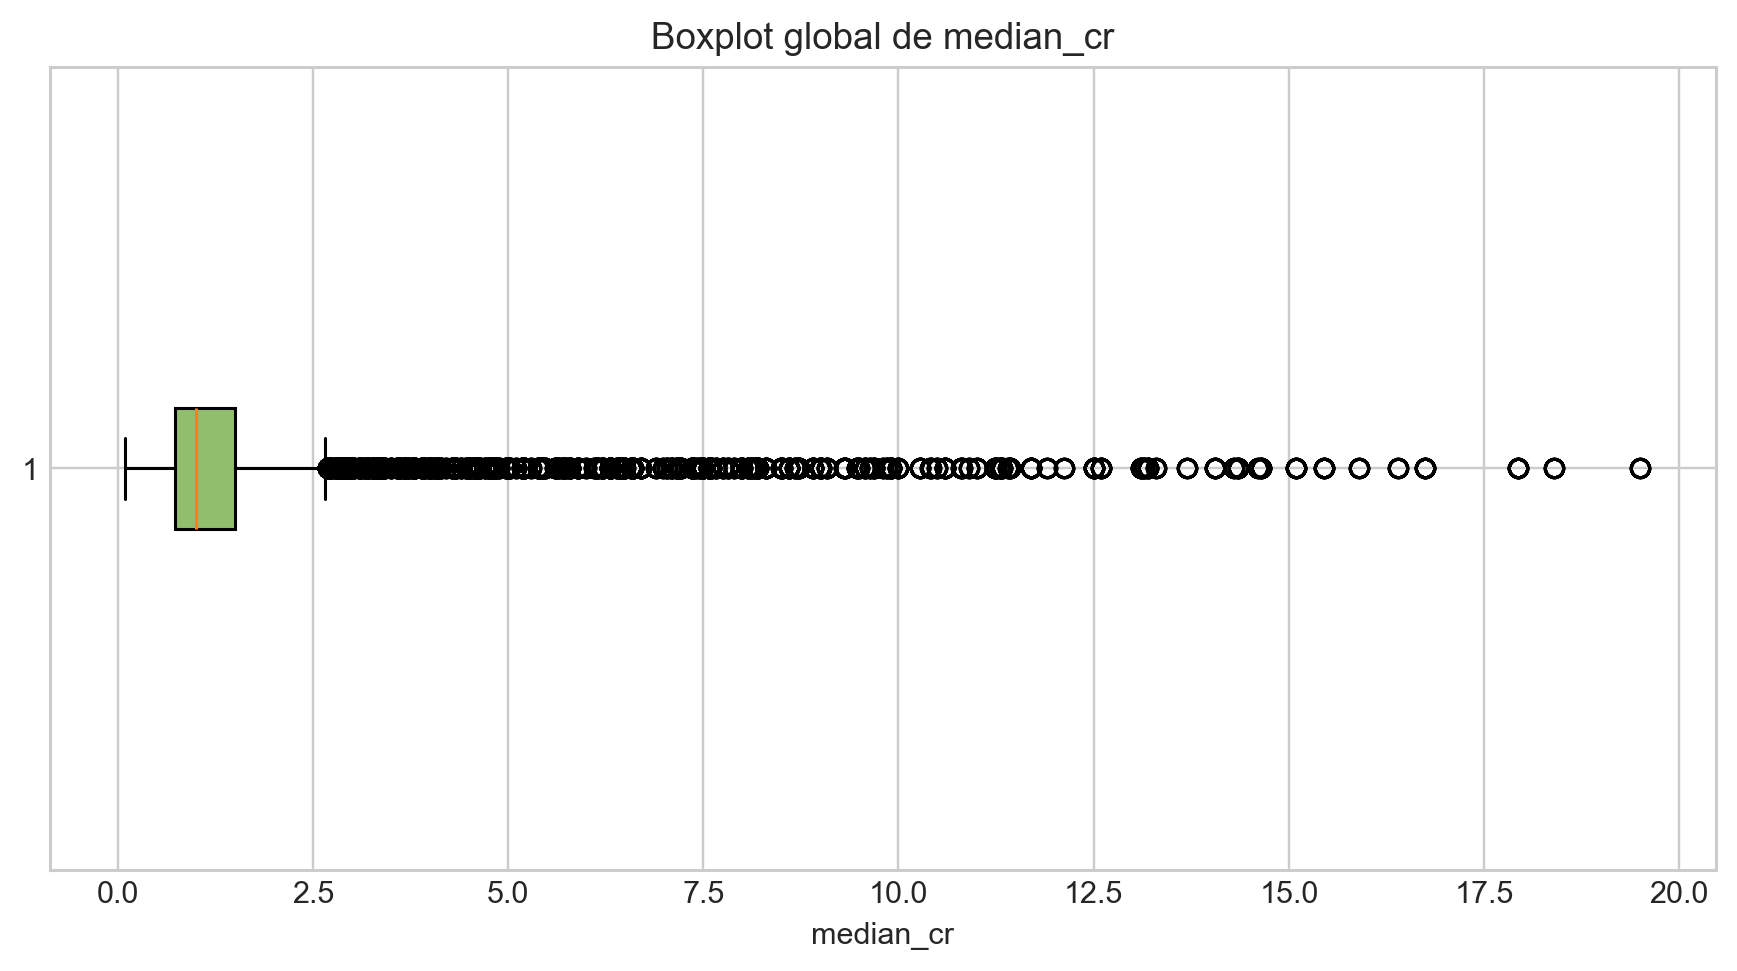

In [8]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_06_boxplot_median_cr.png")))


## 7. Antibioticos mas frecuentes

### Grafica: `expo_07_top_antibioticos.png`

### Que muestra
- los antibioticos mas frecuentes en la cohorte limpia

### Por que da ese resultado
- algunos antibioticos aparecen mucho mas que otros porque son mas relevantes para el contexto clinico o mas usados en el laboratorio

### Mensaje para la exposicion
- la variable `antibiotic` es central porque la resistencia depende del antibiotico evaluado
- el modelo no predice resistencia en abstracto, sino resistencia frente a un antibiotico concreto


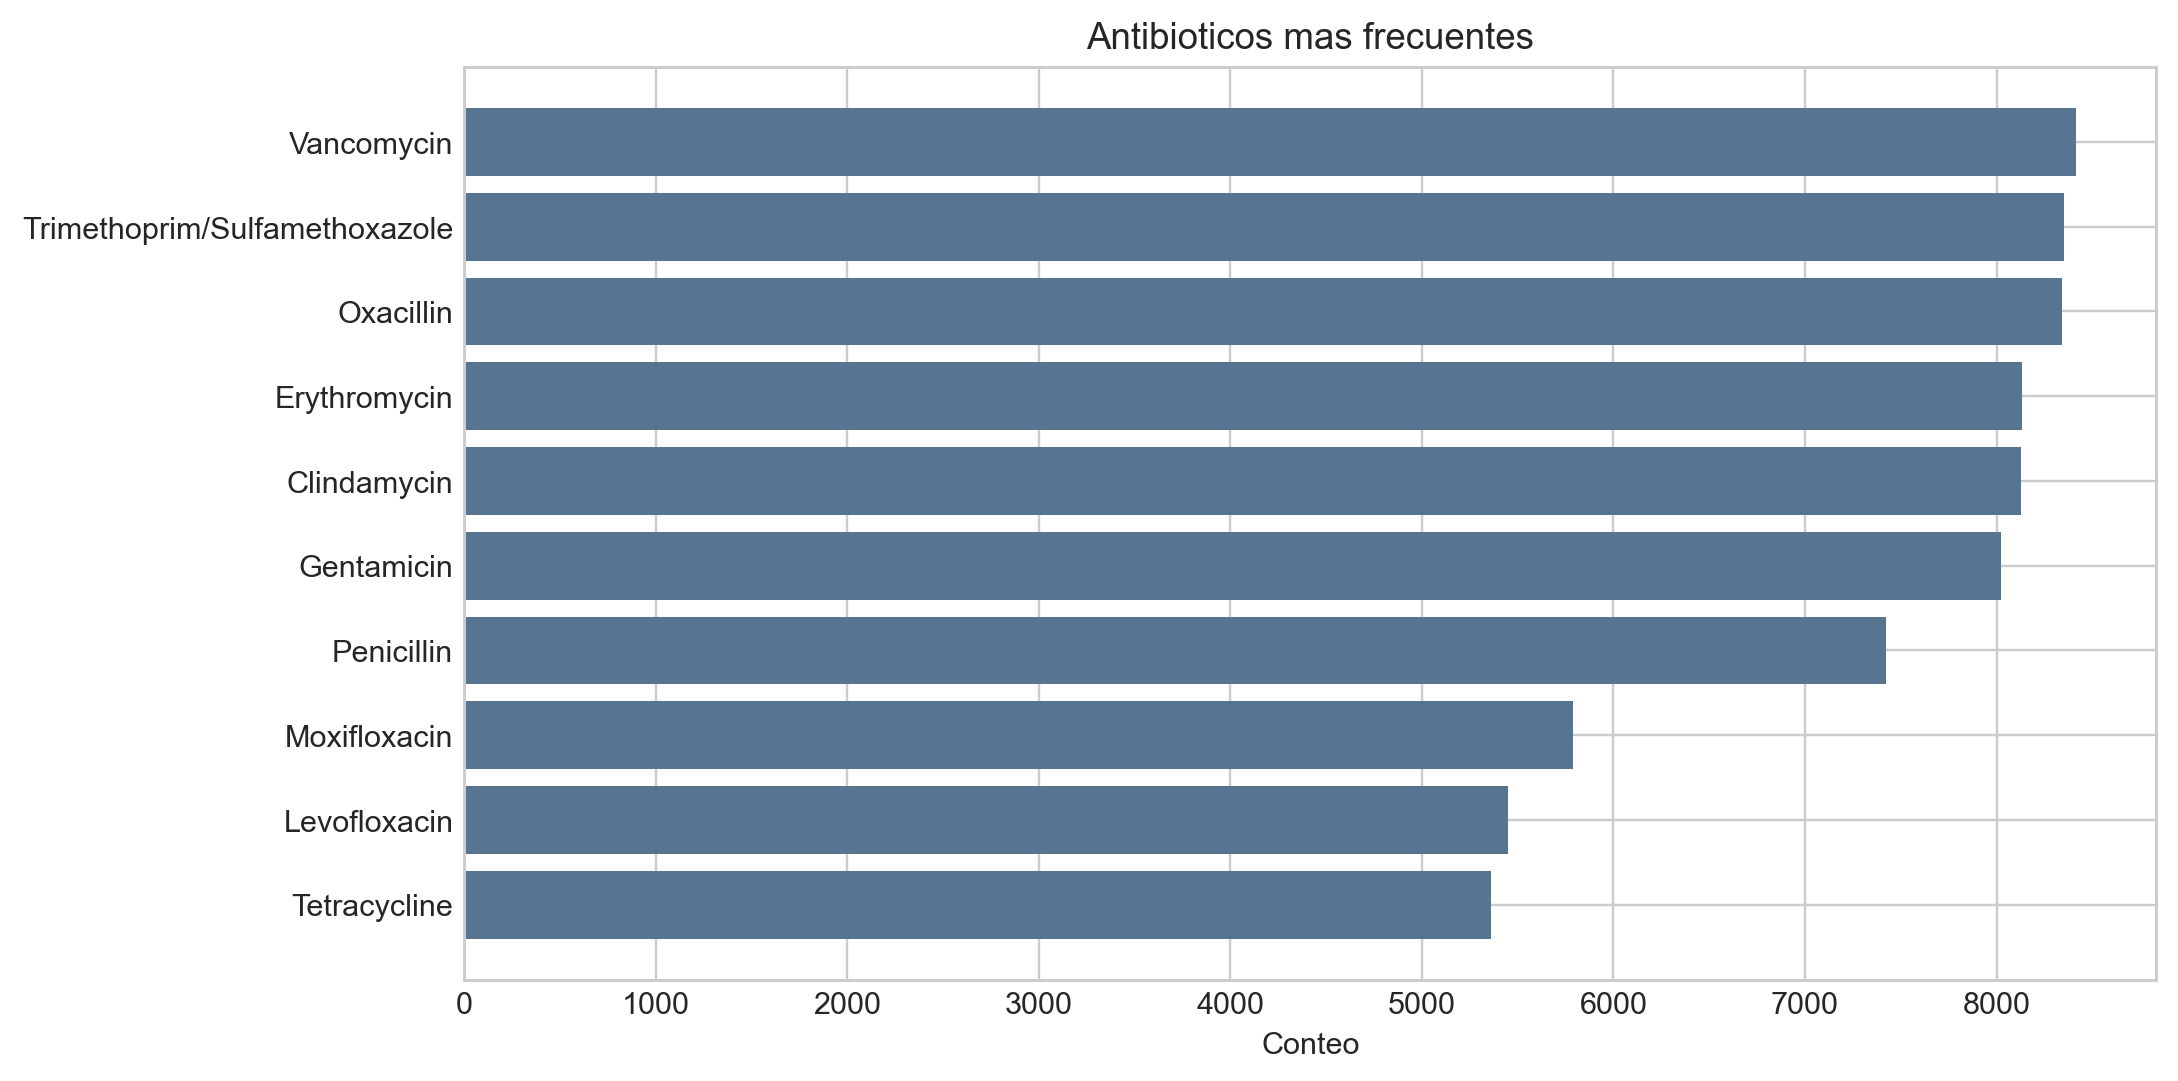

In [9]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_07_top_antibioticos.png")))


## 8. Tipo de cultivo vs susceptibility

### Grafica: `expo_08_cultivo_vs_susceptibilidad.png`

### Que muestra
- la composicion porcentual de `Susceptible`, `Intermediate` y `Resistant` dentro de cada tipo de cultivo

### Por que da ese resultado
- la localizacion anatomica importa
- no es lo mismo una muestra respiratoria que una de sangre u orina
- el comportamiento epidemiologico puede cambiar segun el sitio de infeccion

### Mensaje para la exposicion
- esta es una de las mejores graficas para defender por que `culture_description` se mantuvo como variable importante


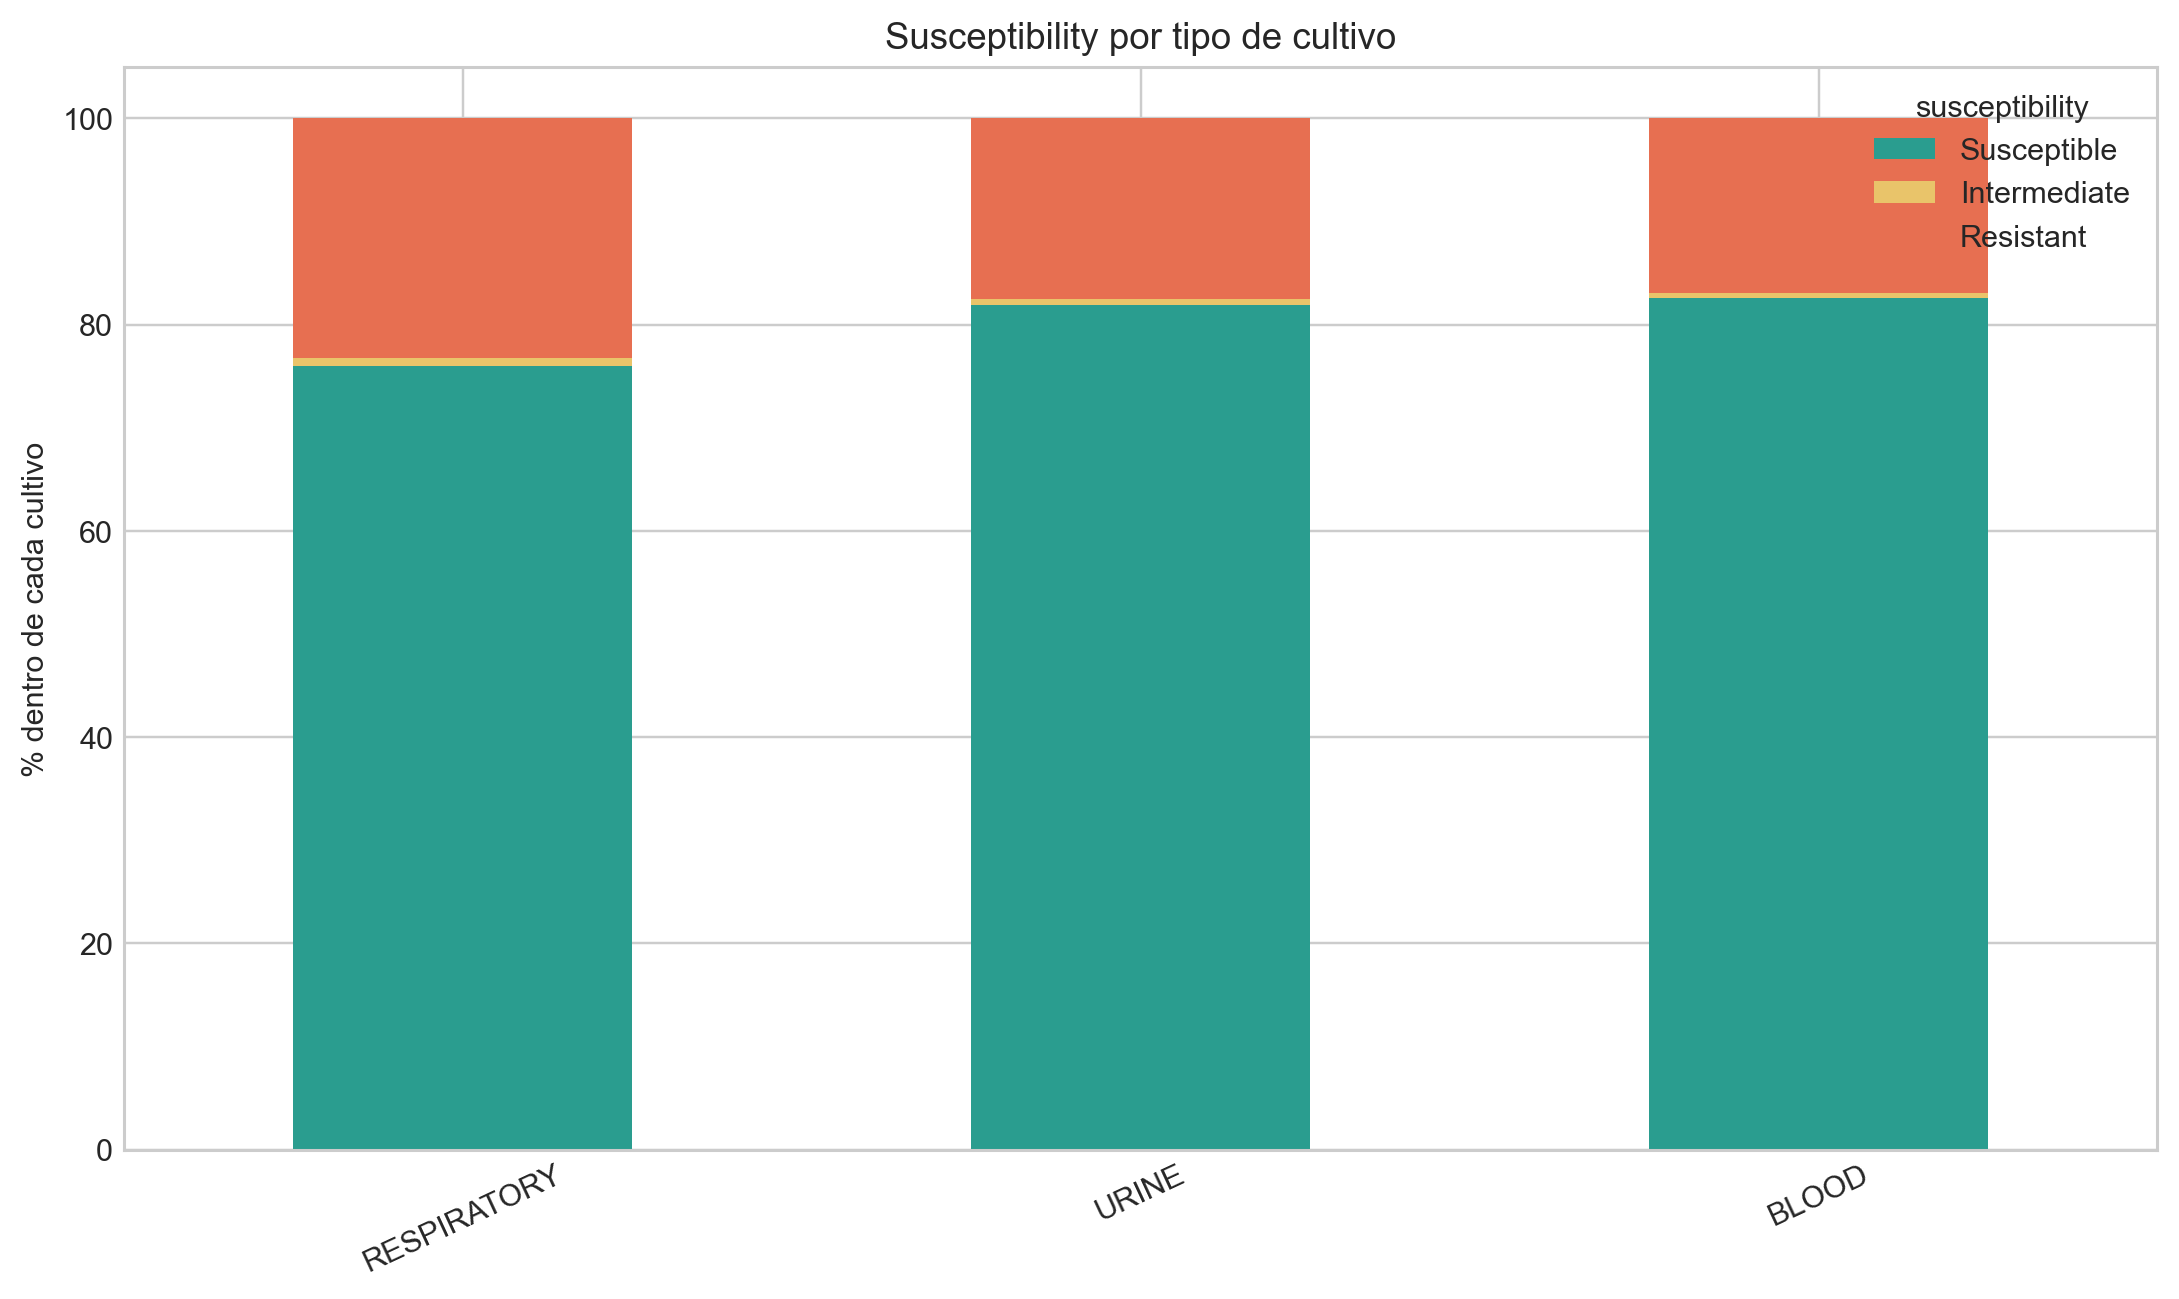

In [10]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_08_cultivo_vs_susceptibilidad.png")))


## 9. Edad vs susceptibility

### Grafica: `expo_09_edad_vs_susceptibilidad.png`

### Que muestra
- distribucion de clases de `susceptibility` a traves de los grupos de edad

### Por que da ese resultado
- la edad se asocia con comorbilidad, mayor exposicion hospitalaria y trayectorias clinicas distintas

### Mensaje para la exposicion
- la edad no se dejo por costumbre, sino por plausibilidad clinica y buena cobertura


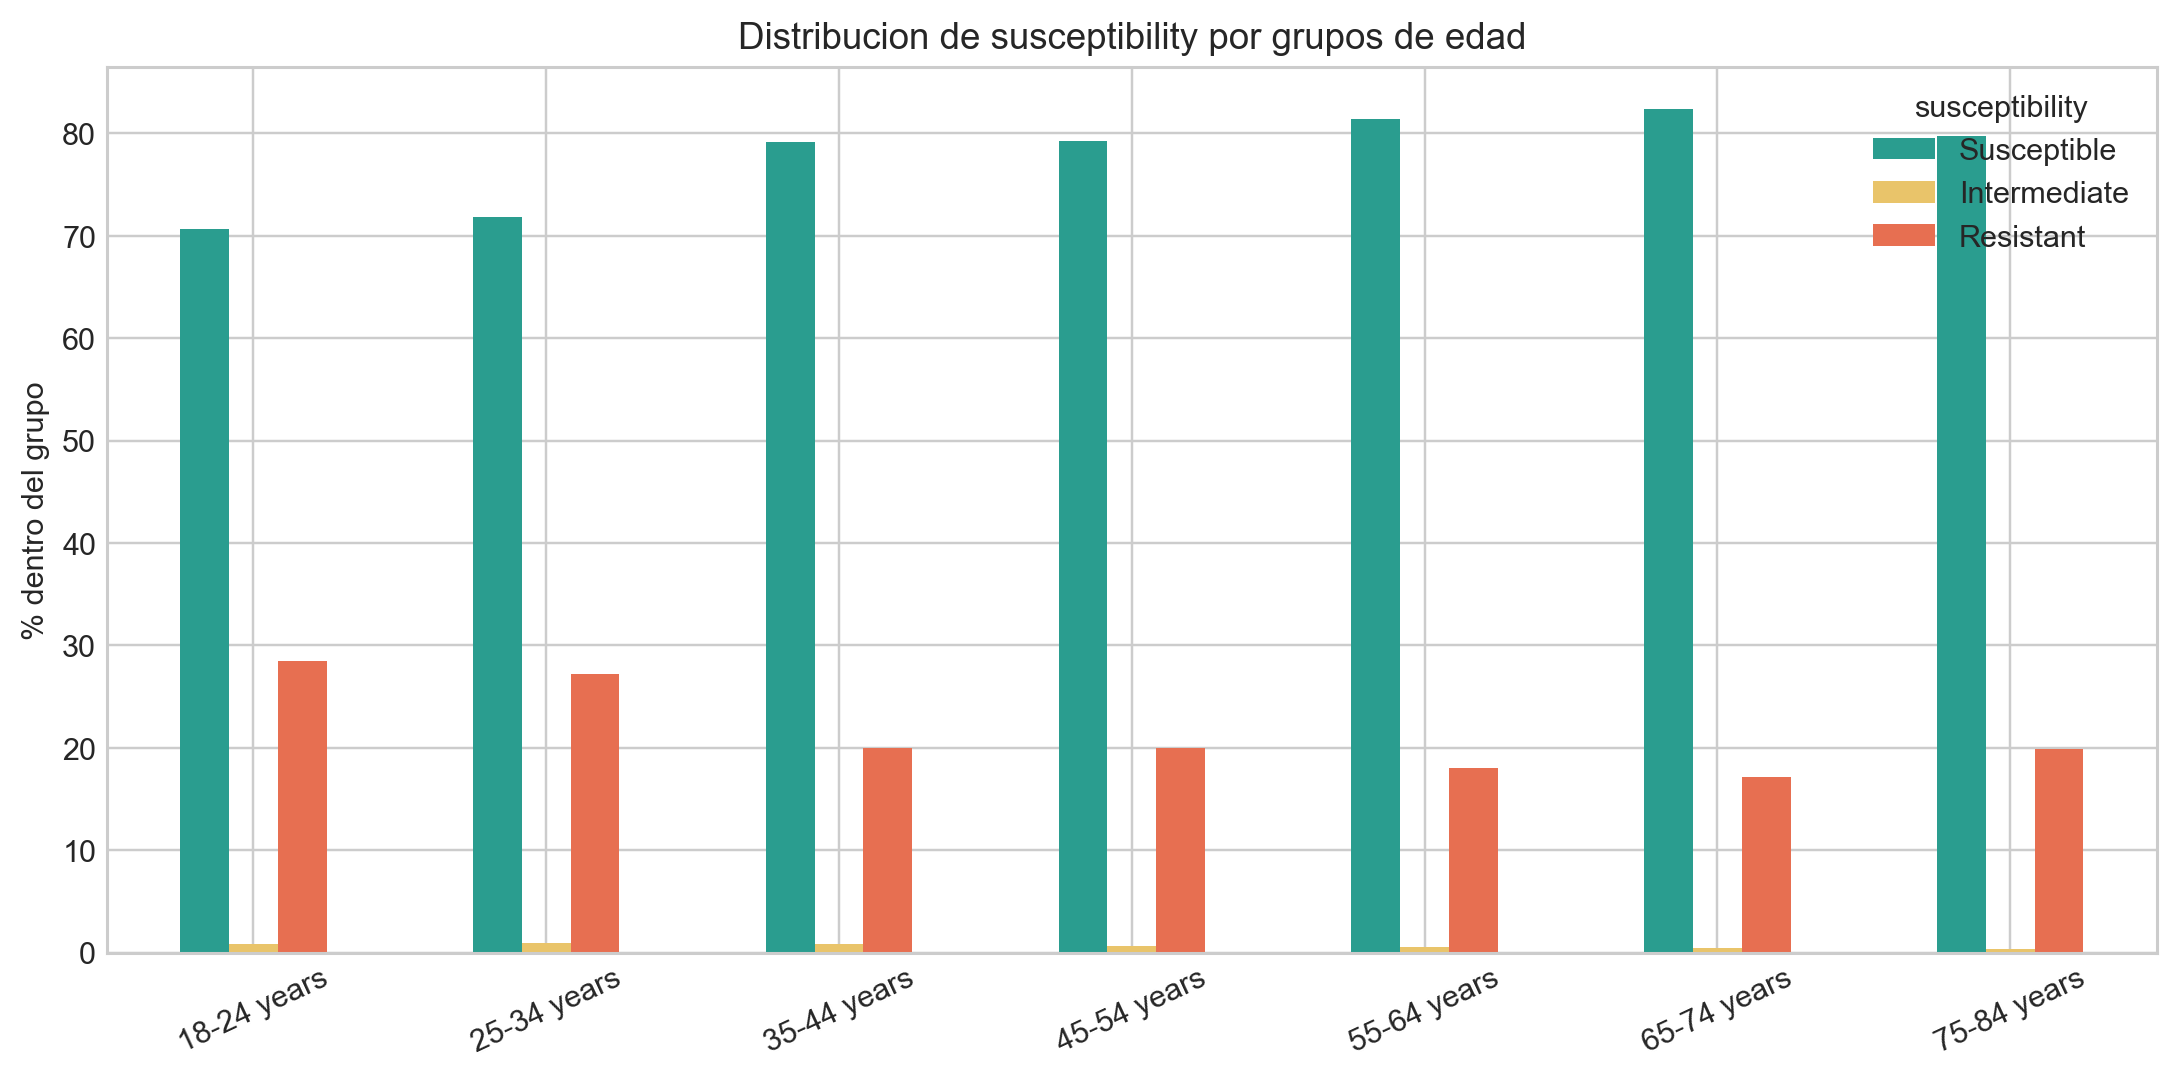

In [11]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_09_edad_vs_susceptibilidad.png")))


## 10. Entorno hospitalario

### Grafica: `expo_10_entorno_hospitalario.png`

### Que muestra
- la proporcion de registros asociados a UCI, urgencias, hospitalizacion y consulta ambulatoria

### Por que da ese resultado
- cada entorno tiene presion antibiotica, complejidad y perfil epidemiologico distintos

### Mensaje para la exposicion
- estas variables ayudan a capturar contexto clinico y no solo datos del antibiograma


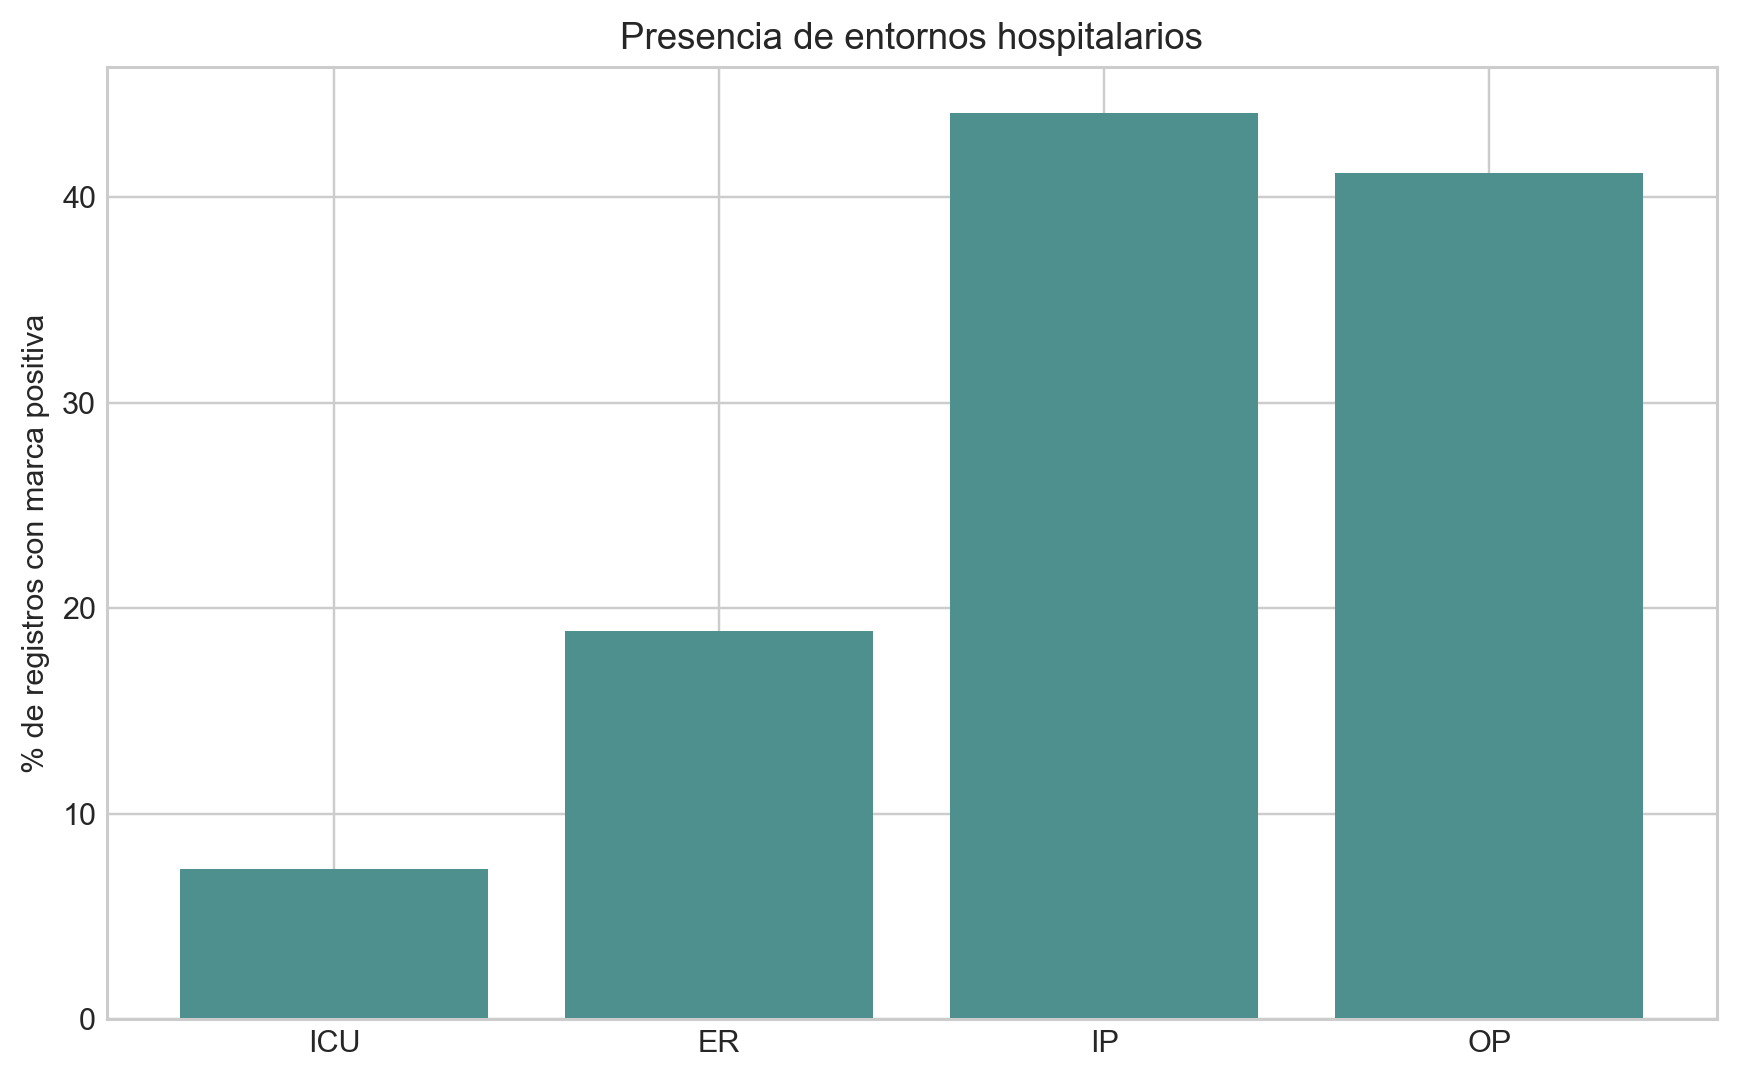

In [12]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_10_entorno_hospitalario.png")))


## 11. Heatmap de correlacion del dataset final

Esta grafica muestra la correlacion entre **todas las variables del dataset final de modelado** y `susceptibility`.

- Se usa la version mas completa: `multihot_abx_comorb`.
- Las variables categoricas se codifican numericamente solo para fines de visualizacion.
- `susceptibility` se codifica como `0 = Susceptible`, `1 = Intermediate`, `2 = Resistant`.

Sirve para ver rapidamente que variables parecen moverse juntas y cuales muestran mayor relacion con la variable objetivo.


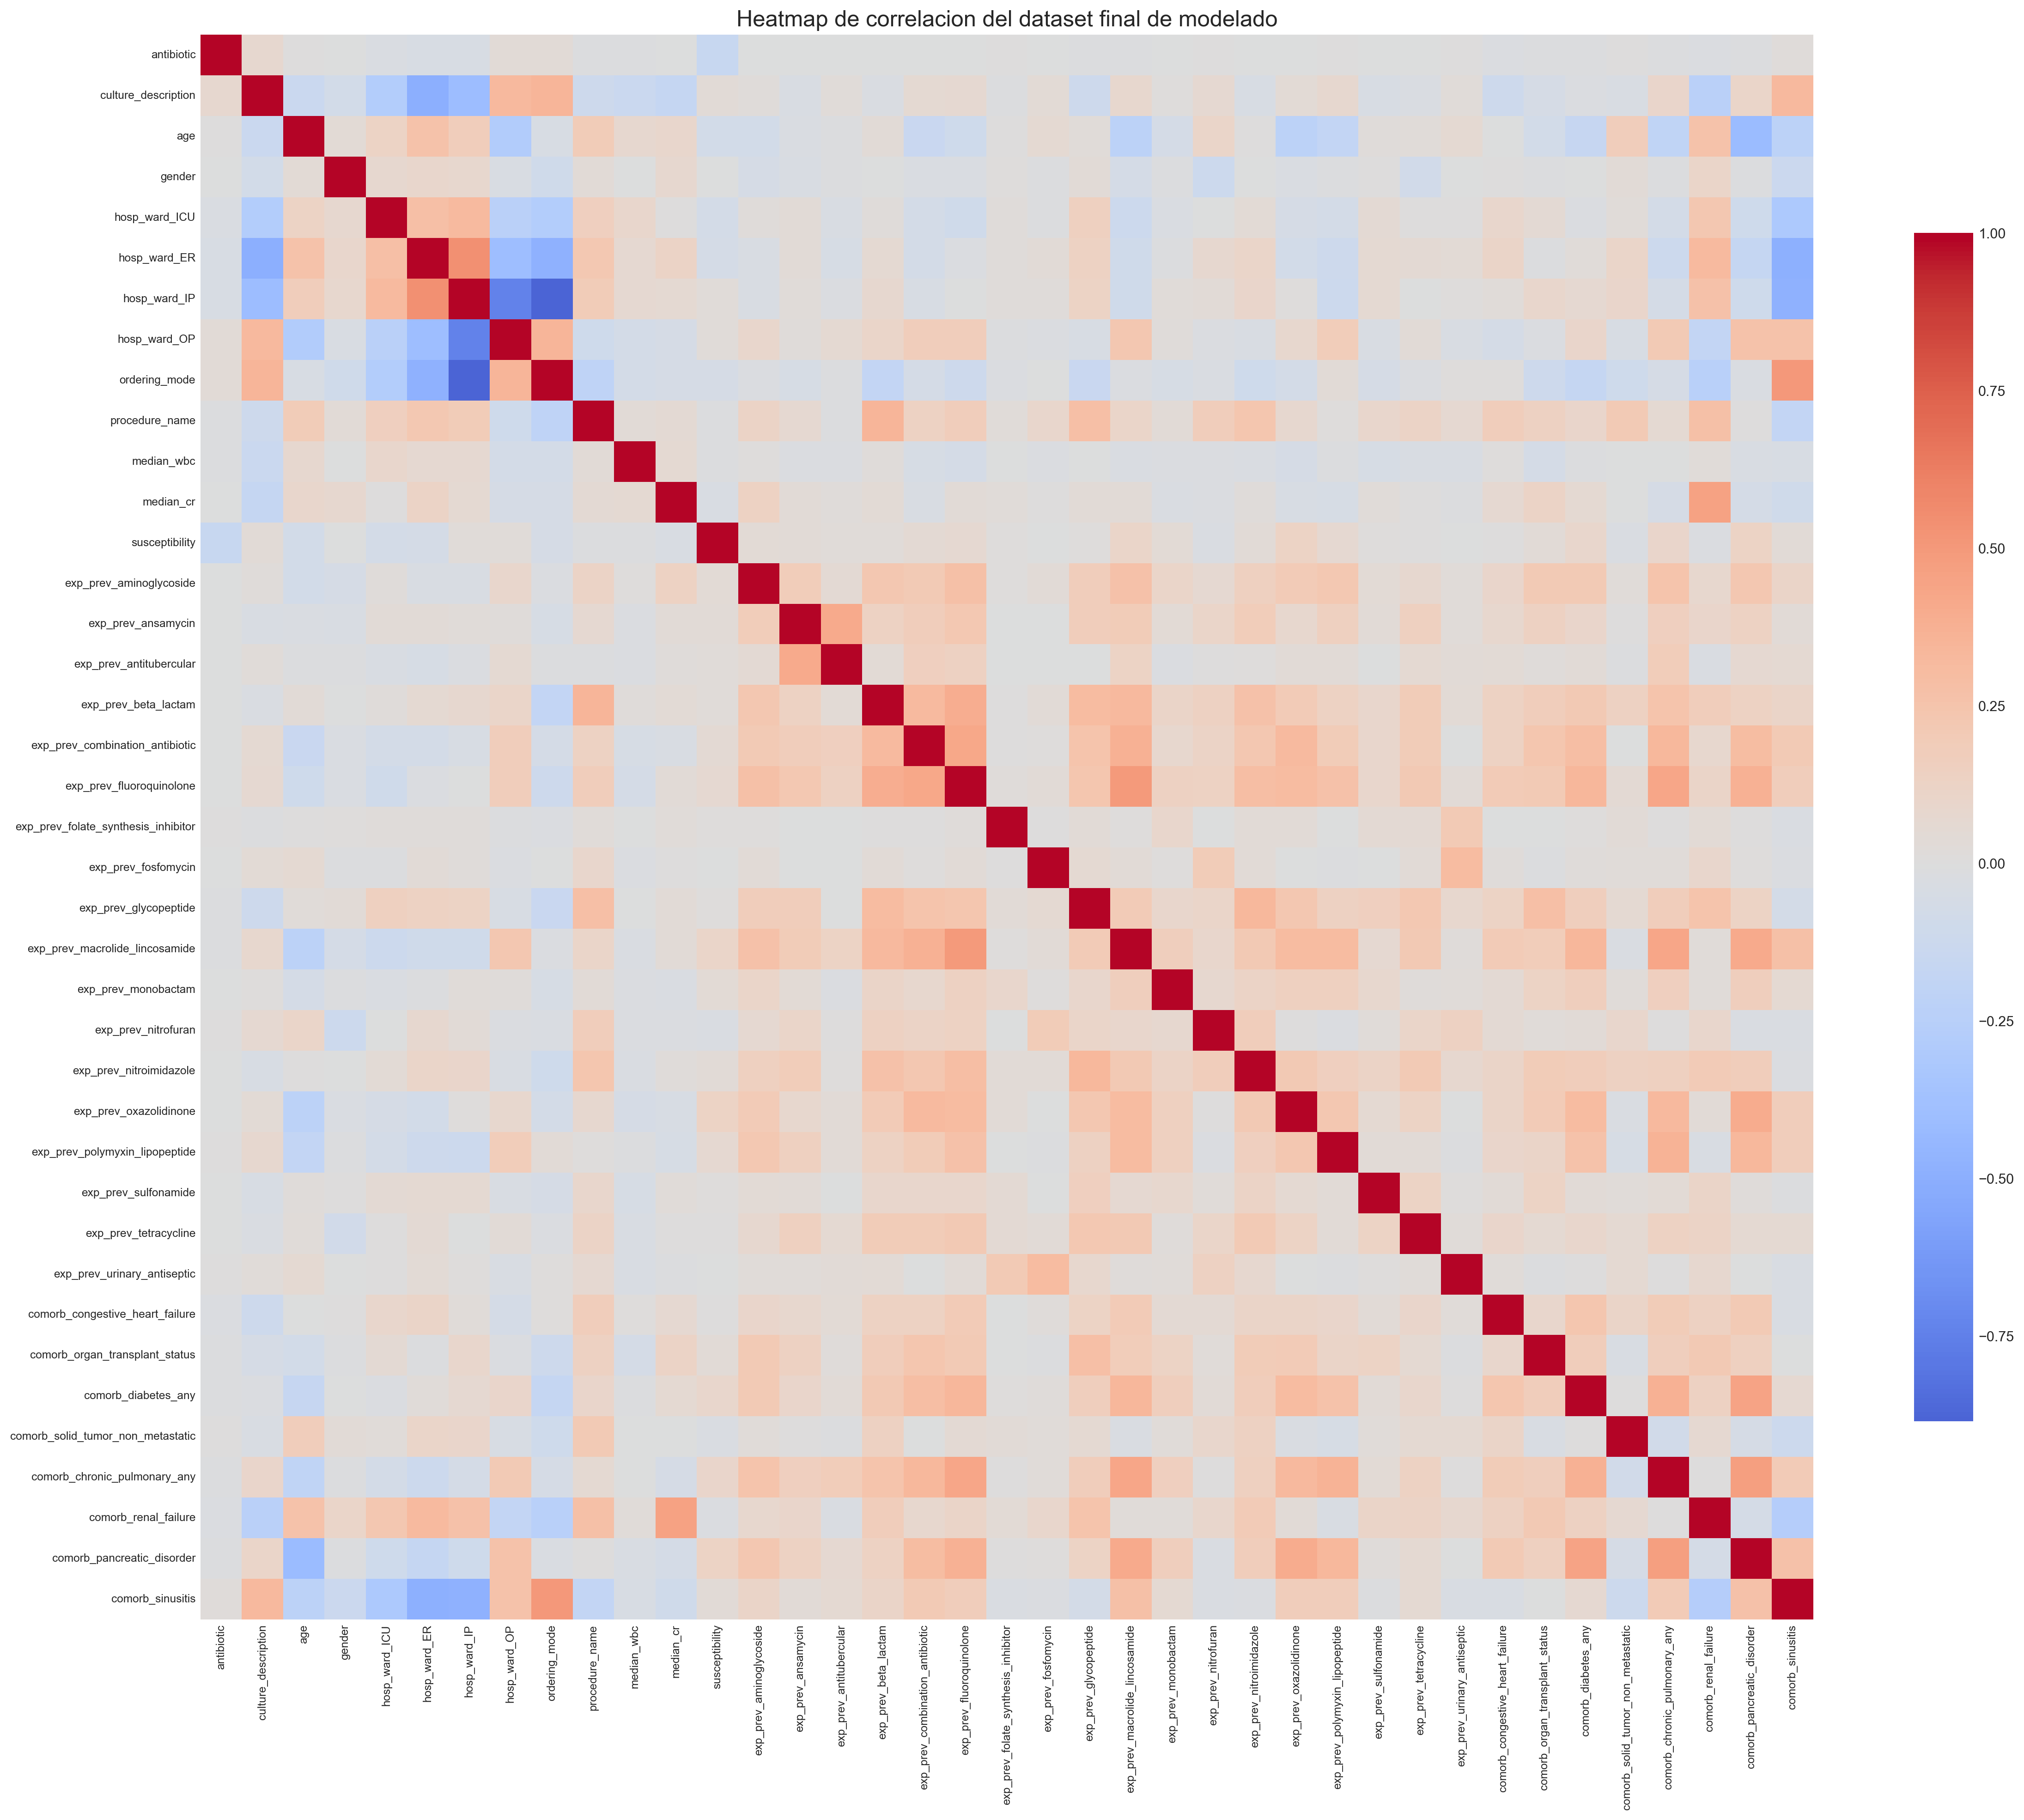

,Unnamed: 0,correlacion_con_susceptibility,correlacion_absoluta
0,antibiotic,-0.155763,0.155763
1,exp_prev_oxazolidinone,0.125630,0.125630
2,comorb_pancreatic_disorder,0.124901,0.124901
3,exp_prev_macrolide_lincosamide,0.105170,0.105170
4,comorb_chronic_pulmonary_any,0.098754,0.098754
5,comorb_diabetes_any,0.089187,0.089187
6,age,-0.082347,0.082347
7,hosp_ward_ICU,-0.071941,0.071941
8,exp_prev_fluoroquinolone,0.069784,0.069784
9,exp_prev_polymyxin_lipopeptide,0.069668,0.069668


In [13]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_12_heatmap_correlacion_modelado_completo.png")))
display(pd.read_csv(RUTA_PROCESADOS / "correlacion_con_susceptibility_modelado_completo.csv").head(15))


## 12. median_wbc segun susceptibility

Este boxplot ya no muestra solo la dispersion global de `median_wbc`, sino como cambia segun cada clase de `susceptibility`.


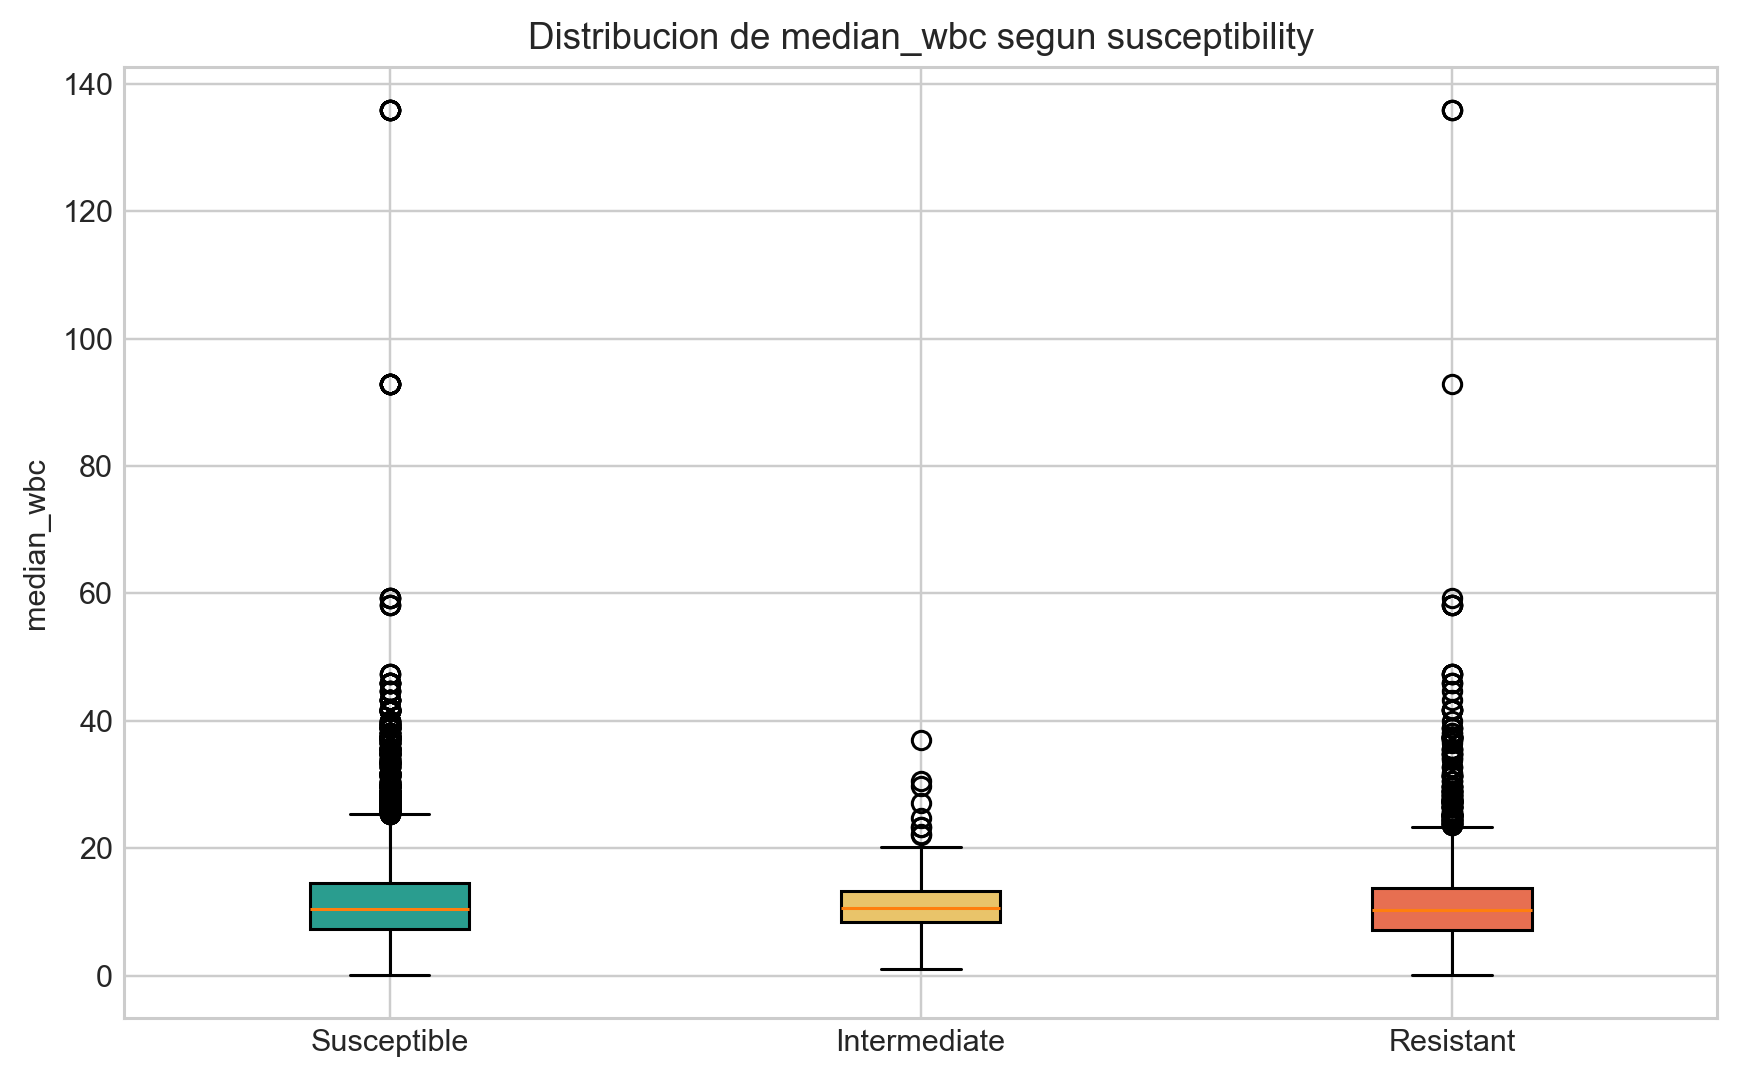

In [14]:
display(Image(filename=str(RUTA_GRAFICAS_EXPO / "expo_13_boxplot_wbc_por_susceptibility.png")))


## Graficas mas recomendadas para la exposicion corta

Si el tiempo es limitado y quieres una historia centrada en `susceptibility`, las mas fuertes para mostrar son:

1. `expo_01_resumen_limpieza`
2. `expo_02_objetivo_antes_despues`
3. `expo_11_faltantes_semanticos`
4. `expo_04_decision_variables`
5. `expo_08_cultivo_vs_susceptibilidad`
6. `expo_09_edad_vs_susceptibilidad`
7. `expo_12_heatmap_correlacion_modelado_completo`
8. `expo_13_boxplot_wbc_por_susceptibility`

Con esas ocho ya puedes contar una historia clara de limpieza, calidad, seleccion de variables y comportamiento de la variable objetivo.
